In [75]:
# packages for Exploratory Data Analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# To display all the columns of dataframe
pd.set_option('display.max_columns', 500)
import warnings
import os

# Data Preprocessing
from sklearn import preprocessing,metrics
from sklearn.preprocessing import LabelEncoder
from IPython.core.display import HTML
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import RFE
from sklearn.datasets import make_regression
from imblearn.over_sampling import SMOTE

# Model Evaluation
%matplotlib inline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import average_precision_score
from sklearn.metrics import precision_recall_curve
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import precision_score, recall_score
import xgboost as xgb


In [76]:
df  = pd.read_csv('LoanDataset.csv')

In [77]:
df.head(10)

,customer_id,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status
0,1.0,22,59000,RENT,123.0,PERSONAL,C,"£35,000.00",16.02,10,Y,3,DEFAULT
1,2.0,21,9600,OWN,5.0,EDUCATION,A,"£1,000.00",11.14,1,NaN,2,NO DEFAULT
2,3.0,25,9600,MORTGAGE,1.0,MEDICAL,B,"£5,500.00",12.87,5,N,3,DEFAULT
3,4.0,23,65500,RENT,4.0,MEDICAL,B,"£35,000.00",15.23,10,N,2,DEFAULT
4,5.0,24,54400,RENT,8.0,MEDICAL,B,"£35,000.00",14.27,10,Y,4,DEFAULT
5,6.0,21,9900,OWN,2.0,VENTURE,A,"£2,500.00",7.14,1,N,2,DEFAULT
6,7.0,26,77100,RENT,8.0,EDUCATION,A,"£35,000.00",12.42,10,NaN,3,NO DEFAULT
7,8.0,24,78956,RENT,5.0,MEDICAL,A,"£35,000.00",11.11,10,NaN,4,NO DEFAULT
8,9.0,24,83000,RENT,8.0,PERSONAL,A,"£35,000.00",8.90,10,NaN,2,NO DEFAULT
9,10.0,21,10000,OWN,6.0,VENTURE,C,"£1,600.00",14.74,1,N,3,DEFAULT


In [78]:
df.shape

(32586, 13)

In [79]:

# Set the display option to show all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Display the data types of each column
print("Data types of each column:")
print(df.dtypes)


Data types of each column:
customer_id            float64
customer_age             int64
customer_income         object
home_ownership          object
employment_duration    float64
loan_intent             object
loan_grade              object
loan_amnt               object
loan_int_rate          float64
term_years               int64
historical_default      object
cred_hist_length         int64
Current_loan_status     object
dtype: object


In [80]:

# Set the display option to show all rows
pd.set_option('display.max_rows', None)

# Calculating the percentage of missing values in each column
missing_percentage = (df.isnull().mean() * 100).round(2)

# Display the result
print("Percentage of missing values in each column:")
print(missing_percentage)


Percentage of missing values in each column:
customer_id             0.01
customer_age            0.00
customer_income         0.00
home_ownership          0.00
employment_duration     2.75
loan_intent             0.00
loan_grade              0.00
loan_amnt               0.00
loan_int_rate           9.56
term_years              0.00
historical_default     63.64
cred_hist_length        0.00
Current_loan_status     0.01
dtype: float64


In [85]:
# Convert monetary and percentage values to numeric
df['loan_amnt'] = df['loan_amnt'].replace('[\£,]', '', regex=True).astype(float)
df['loan_int_rate'] = df['loan_int_rate'].astype(float)

In [86]:
# Convert target variable to binary format
df['Current_loan_status'] = df['Current_loan_status'].apply(lambda x: 1 if x == 'DEFAULT' else 0)

In [87]:
# Convert categorical variables to numeric using Label Encoding
le = LabelEncoder()
categorical_columns = ['home_ownership', 'loan_intent', 'loan_grade', 'historical_default']


In [88]:
le = LabelEncoder()
categorical_columns = ['home_ownership', 'loan_intent', 'loan_grade', 'historical_default']

for col in categorical_columns:
    df[col] = le.fit_transform(df[col].astype(str))

# One-Hot Encoding for categorical variables
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

In [91]:
# Separate features and target
X = df_encoded.drop(['customer_id', 'Current_loan_status'], axis=1)
y = df_encoded['Current_loan_status']

In [92]:
df['Current_loan_status'].value_counts()

Current_loan_status
0    25742
1     6840
Name: count, dtype: int64

ValueError: Input X contains NaN.
SMOTE does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [59]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values before imputation:")
print(missing_values)

# Impute missing values with the mean for numerical columns
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

for column in numerical_columns:
    mean_value = df[column].mean()
    df[column].fillna(mean_value, inplace=True)

# Verify that missing values have been imputed
missing_values_after = df.isnull().sum()
print("\nMissing values after imputation:")
print(missing_values_after)

Missing values before imputation:
customer_age              0
customer_income           0
home_ownership            0
employment_duration     895
loan_intent               0
loan_grade                0
loan_amnt                 1
loan_int_rate          3116
term_years                0
cred_hist_length          0
Current_loan_status       4
dtype: int64

Missing values after imputation:
customer_age           0
customer_income        0
home_ownership         0
employment_duration    0
loan_intent            0
loan_grade             0
loan_amnt              1
loan_int_rate          0
term_years             0
cred_hist_length       0
Current_loan_status    4
dtype: int64


In [60]:
df['Current_loan_status'].value_counts()

Current_loan_status
NO DEFAULT    25742
DEFAULT        6840
Name: count, dtype: int64

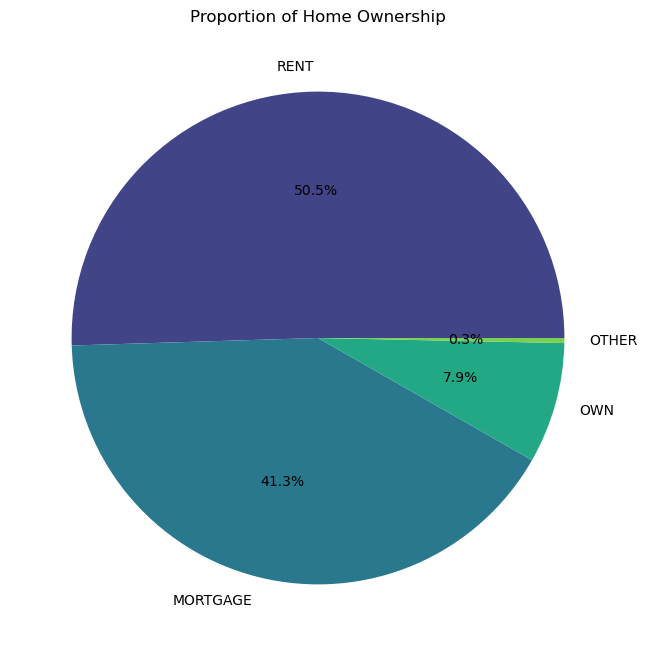

In [61]:
# Data Analysis and Visualization for Home_ownership
# Pie chart for home_ownership
plt.figure(figsize=(8, 8))
df['home_ownership'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('viridis', df['home_ownership'].nunique()))
plt.title('Proportion of Home Ownership')
plt.ylabel('')  # Hide the y-label
plt.show()


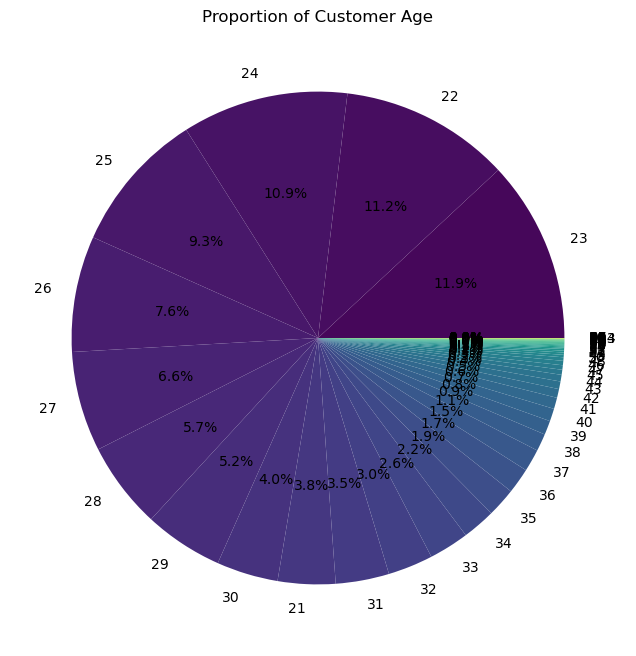

In [62]:
# Pie chart for home_ownership
plt.figure(figsize=(8, 8))
df['customer_age'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('viridis', df['customer_age'].nunique()))
plt.title('Proportion of Customer Age')
plt.ylabel('')  # Hide the y-label
plt.show()


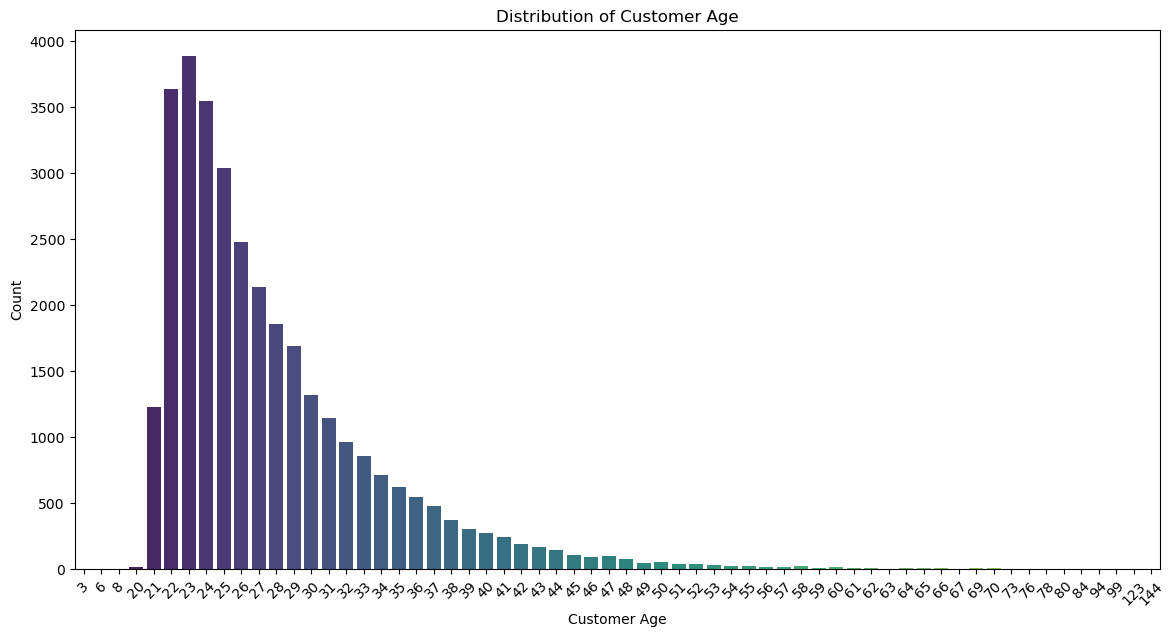

In [63]:
# Bar plot for each unique age value
plt.figure(figsize=(14, 7))
sns.countplot(data=df, x='customer_age', palette='viridis')
plt.title('Distribution of Customer Age')
plt.xlabel('Customer Age')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


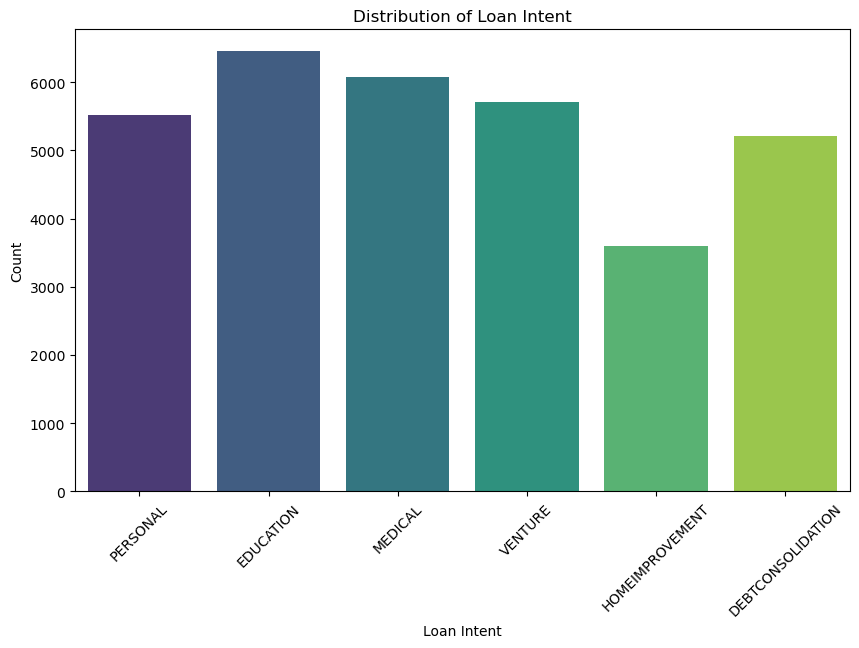

In [64]:
# Bar plot for loan_intent
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='loan_intent', palette='viridis')
plt.title('Distribution of Loan Intent')
plt.xlabel('Loan Intent')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


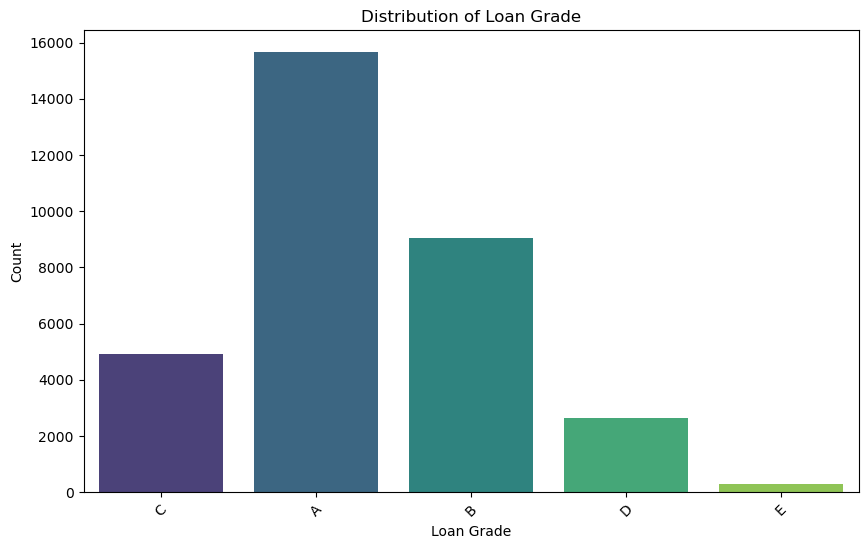

In [65]:
# Bar plot for loan_grade
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='loan_grade', palette='viridis')
plt.title('Distribution of Loan Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


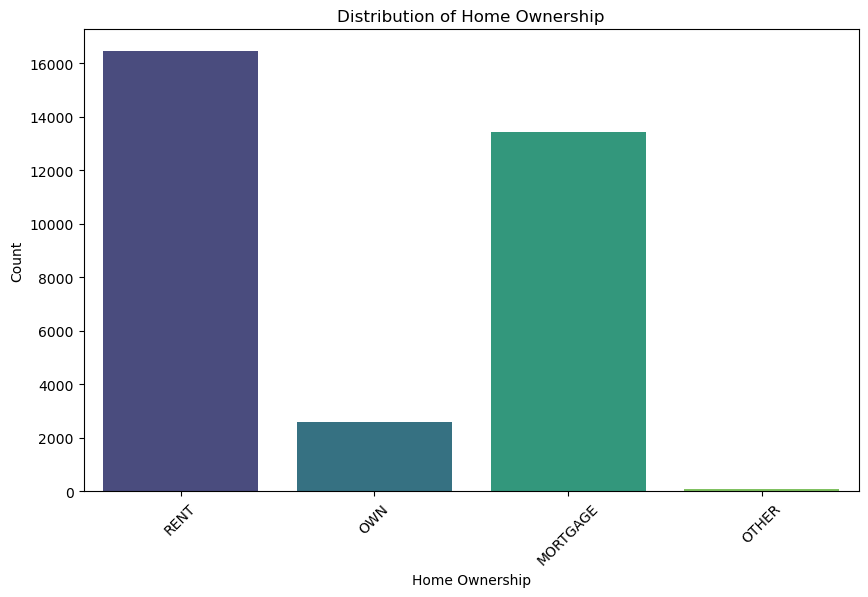

In [66]:
# Bar plot for home_ownership
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='home_ownership', palette='viridis')
plt.title('Distribution of Home Ownership')
plt.xlabel('Home Ownership')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

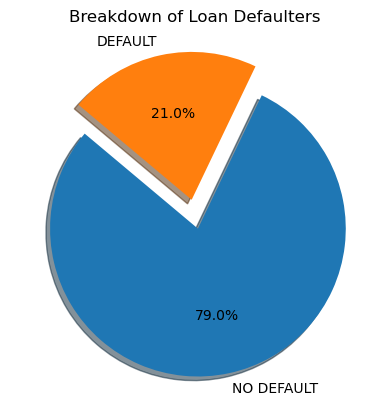

In [67]:
# Data Analysis
status_counts = df['Current_loan_status'].value_counts()

plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', shadow=True, explode=[0.1, 0.1], startangle=140)
plt.title('Breakdown of Loan Defaulters')
plt.show()

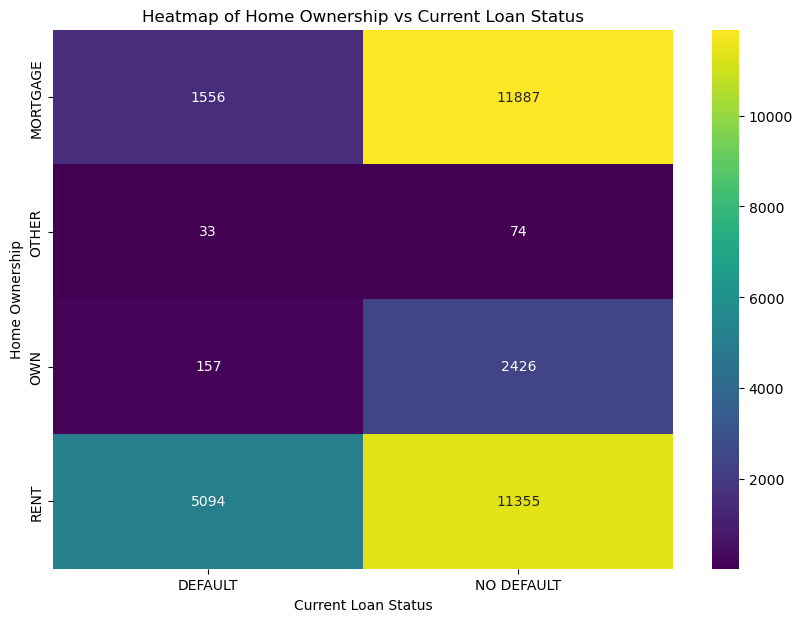

In [68]:
 # multi variate analysis
# Create a crosstab table
crosstab = pd.crosstab(df['home_ownership'], df['Current_loan_status'])

# Plot the heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='viridis')
plt.title('Heatmap of Home Ownership vs Current Loan Status')
plt.xlabel('Current Loan Status')
plt.ylabel('Home Ownership')
plt.show()


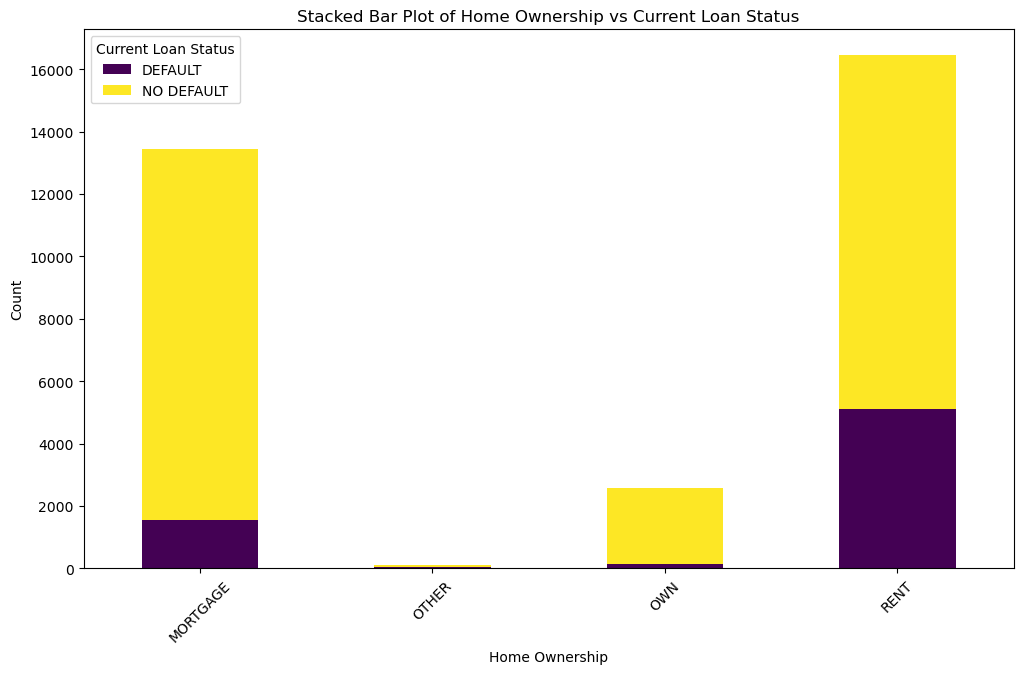

In [69]:

# Create a crosstab table
crosstab = pd.crosstab(df['home_ownership'], df['Current_loan_status'])

# Plot the stacked bar plot
crosstab.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')
plt.title('Stacked Bar Plot of Home Ownership vs Current Loan Status')
plt.xlabel('Home Ownership')
plt.ylabel('Count')
plt.legend(title='Current Loan Status')
plt.xticks(rotation=45)
plt.show()


In [70]:
# Create a crosstab table
crosstab = pd.crosstab(df['loan_grade'], df['Current_loan_status'])
print("Crosstab Table:")
print(crosstab)

Crosstab Table:
Current_loan_status  DEFAULT  NO DEFAULT
loan_grade                              
A                       1567       14093
B                       1751        7313
C                       1761        3164
D                       1540        1088
E                        221          84


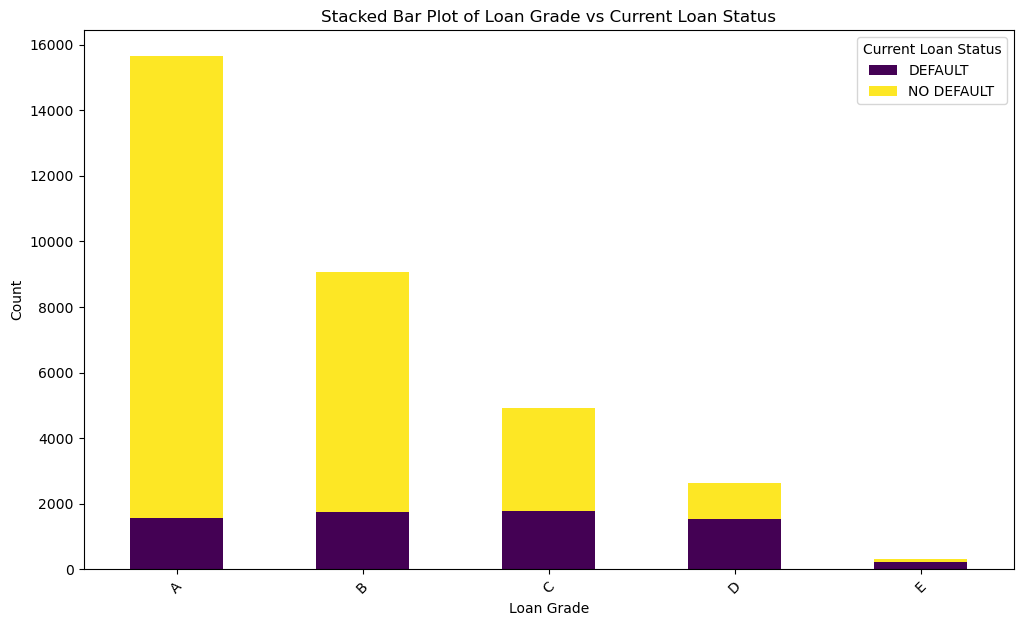

In [71]:
# Create a crosstab table
crosstab = pd.crosstab(df['loan_grade'], df['Current_loan_status'])

# Plot the stacked bar plot
crosstab.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')
plt.title('Stacked Bar Plot of Loan Grade vs Current Loan Status')
plt.xlabel('Loan Grade')
plt.ylabel('Count')
plt.legend(title='Current Loan Status')
plt.xticks(rotation=45)
plt.show()

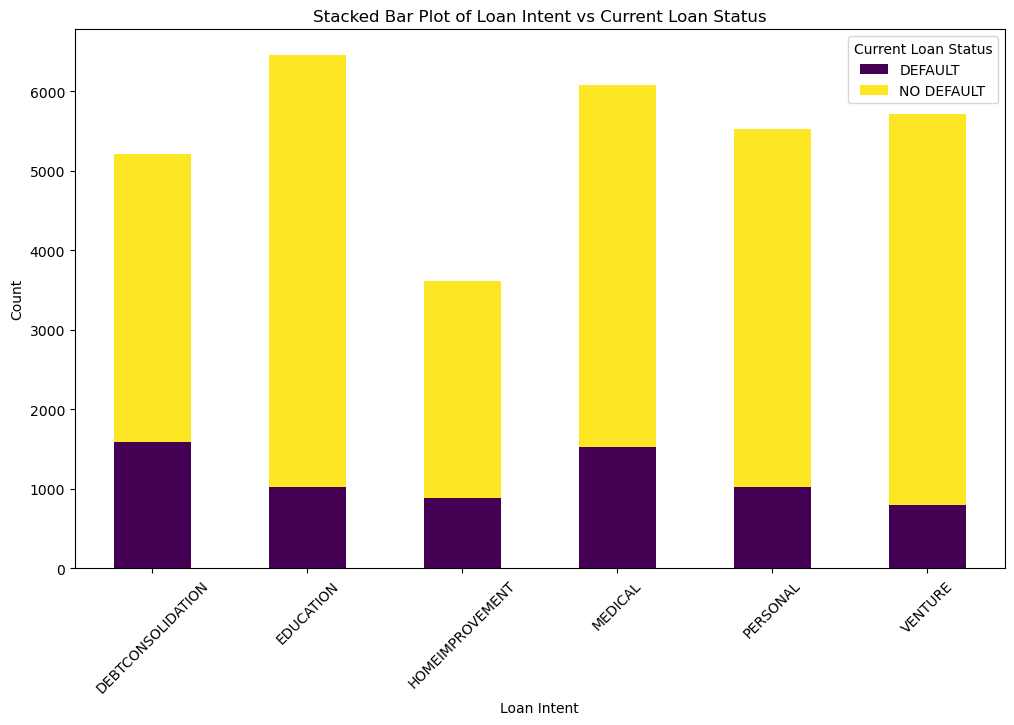

In [72]:

# Create a crosstab table
crosstab = pd.crosstab(df['loan_intent'], df['Current_loan_status'])

# Plot the stacked bar plot
crosstab.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')
plt.title('Stacked Bar Plot of Loan Intent vs Current Loan Status')
plt.xlabel('Loan Intent')
plt.ylabel('Count')
plt.legend(title='Current Loan Status')
plt.xticks(rotation=45)
plt.show()


In [73]:

# Sample DataFrame creation for demonstration purposes
data = {
    'Current_loan_status': ['Default', 'No-Default', 'Default', 'No-Default', 'Default'],
    'Other_column': [10, 20, 30, 40, 50]  # Example of another column
}
df = pd.DataFrame(data)

# Convert 'Current_loan_status' to numerical values
df['Current_loan_status'] = df['Current_loan_status'].map({'Default': 1, 'No-Default': 0})

# Verify the conversion
print(df)

   Current_loan_status  Other_column
0                    1            10
1                    0            20
2                    1            30
3                    0            40
4                    1            50


In [74]:
# training features

# Define the features and target variable
features = ['customer_age', 'customer_income', 'home_ownership', 'employment_duration', 'loan_intent',
                     'loan_grade', 'loan_amnt','loan_int_rate', 'term_years','cred_hist_length',]

target_variable = 'Current_loan_status'

# Select the features and target variable
final = df[features + [target_variable]]



# Reset the index
final = final.reset_index(drop=True)

# Print the current shape of the dataset
print("Current shape of df:", final.shape)


KeyError: "['customer_age', 'customer_income', 'home_ownership', 'employment_duration', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'term_years', 'cred_hist_length'] not in index"

In [24]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Display the data types of each column
print("Data types of each column:")
print(final.dtypes)

Data types of each column:
customer_age             int64
customer_income         object
home_ownership          object
employment_duration    float64
loan_intent             object
loan_grade              object
loan_amnt               object
loan_int_rate          float64
term_years               int64
cred_hist_length         int64
Current_loan_status     object
dtype: object


In [25]:
#label encoding categorical values

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Convert categorical columns to integers using label encoding
final['customer_income'] = label_encoder.fit_transform(final['customer_income'])
final['home_ownership'] = label_encoder.fit_transform(final['home_ownership'])
final['loan_intent'] = label_encoder.fit_transform(final['loan_intent'])
final['loan_grade'] = label_encoder.fit_transform(final['loan_grade'])
final['loan_amnt'] = label_encoder.fit_transform(final['loan_amnt'])

In [26]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Display the data types of each column
print("Data types of each column:")
print(final.dtypes)

Data types of each column:
customer_age             int64
customer_income          int32
home_ownership           int32
employment_duration    float64
loan_intent              int32
loan_grade               int32
loan_amnt                int32
loan_int_rate          float64
term_years               int64
cred_hist_length         int64
Current_loan_status     object
dtype: object


In [27]:
data = {'Current_loan_status': ['Default', 'No-Default', 'Default', 'No-Default', 'Default']}
final = pd.DataFrame(data)
final['Current_loan_status'] = final['Current_loan_status'].map({'Default': 1, 'No-Default': 0})
print(final)


   Current_loan_status
0                    1
1                    0
2                    1
3                    0
4                    1


In [28]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Display the data types of each column
print("Data types of each column:")
print(final.dtypes)

Data types of each column:
Current_loan_status    int64
dtype: object


In [ ]:
# target variable definition

# Sample DataFrame creation for demonstration purposes
data = {'Current_loan_status': ['Default', 'No-Default', 'Default', 'No-Default', 'Default']}
df = pd.DataFrame(data)

# Convert 'Current_loan_status' to numerical values
df['Current_loan_status'] = df['Current_loan_status'].map({'Default': 1, 'No-Default': 0})

# Verify the conversion
print(df)


In [24]:
#target variable definition

# Convert 'Current_loan_status' to numerical values
df['Current_loan_status'] = df['Current_loan_status'].map({'Default': 1, 'No-Default': 0})

# Verify the conversion
print(df.head())

   customer_age customer_income home_ownership  employment_duration  \
0            22           59000           RENT                123.0   
1            21            9600            OWN                  5.0   
2            25            9600       MORTGAGE                  1.0   
3            23           65500           RENT                  4.0   
4            24           54400           RENT                  8.0   

  loan_intent loan_grade   loan_amnt  loan_int_rate  term_years  \
0    PERSONAL          C  £35,000.00          16.02          10   
1   EDUCATION          A   £1,000.00          11.14           1   
2     MEDICAL          B   £5,500.00          12.87           5   
3     MEDICAL          B  £35,000.00          15.23          10   
4     MEDICAL          B  £35,000.00          14.27          10   

   cred_hist_length  Current_loan_status  
0                 3                  NaN  
1                 2                  NaN  
2                 3                  NaN 

In [25]:

# Sample DataFrame creation for demonstration purposes
data = {'Current_loan_status': ['Default', 'No-Default', 'Default', 'No-Default', 'Default']}
df = pd.DataFrame(data)

# Convert 'Current_loan_status' to numerical values
df['Current_loan_status'] = df['Current_loan_status'].map({'Default': 1, 'No-Default': 0})

# Verify the conversion
print(df)


   Current_loan_status
0                    1
1                    0
2                    1
3                    0
4                    1


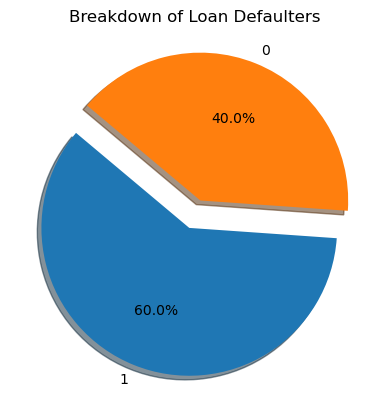

In [26]:
# Data Analysis
status_counts = df['Current_loan_status'].value_counts()

plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', shadow=True, explode=[0.1, 0.1], startangle=140)
plt.title('Breakdown of Loan Defaulters')
plt.show()

In [30]:
 print("Data types of features:")
print(X_train.dtypes)


Data types of features:
Series([], dtype: object)


In [34]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [35]:
# random forest code

# Separate features and target variable
X = df.drop(columns=['Current_loan_status'])
y = df['Current_loan_status']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train the Random Forest classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = clf.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[1 1]
 [0 1]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



In [37]:
# decision trees
from sklearn.tree import DecisionTreeClassifier
# Separate features and target variable
X = df.drop(columns=['Current_loan_status'])
y = df['Current_loan_status']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train the Decision Tree classifier
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = clf.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[1 1]
 [0 1]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Sample DataFrame creation for demonstration purposes
# df = pd.read_csv('your_file.csv')  # Load your data

# Separate features and target variable
X = df.drop(columns=['Current_loan_status'])
y = df['Current_loan_status']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define the parameter grid for Random Forest
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Initialize the Random Forest classifier
rf = RandomForestClassifier(random_state=42)

# Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=3)  # Adjust n_splits based on class distribution

# Initialize GridSearchCV with StratifiedKFold
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=skf, n_jobs=-1, verbose=2)

# Fit GridSearchCV to the data
grid_search.fit(X_train, y_train)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters Found:")
print(best_params)
print(f"Best Cross-Validation Score: {best_score:.4f}")

# Evaluate the best model on the test set
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Fitting 3 folds for each of 216 candidates, totalling 648 fits
Best Parameters Found:
{'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Validation Score: 1.0000
Confusion Matrix:
[[1 1]
 [0 1]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



In [40]:
# naive bayes
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix


# Separate features and target variable
X = df.drop(columns=['Current_loan_status'])
y = df['Current_loan_status']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train the Naive Bayes classifier
clf = GaussianNB()
clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = clf.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[2 0]
 [0 1]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [41]:
from sklearn.naive_bayes import MultinomialNB

# Initialize and train the Naive Bayes classifier
clf = MultinomialNB()
clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = clf.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[2 0]
 [0 1]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [42]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Separate features and target variable
X = df.drop(columns=['Current_loan_status'])
y = df['Current_loan_status']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train the Multi-Layer Perceptron classifier
mlp = MLPClassifier(random_state=42, max_iter=500)  # max_iter is the number of iterations for optimization
mlp.fit(X_train, y_train)

# Make predictions on the test set
y_pred = mlp.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[2 0]
 [0 1]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

